In [1]:
from __future__ import division, print_function
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table, vstack, hstack
import fitsio
import sys, os, glob, time, warnings, gc
# import healpy as hp

from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LogNorm

sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/Users/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [6]:
cat0 = Table(fitsio.read('/Volumes/Samsung T5/tmp/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_basic.fits'))
cat = Table(fitsio.read('/Volumes/Samsung T5/tmp/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_photom.fits'))
cat1 = Table(fitsio.read('/Volumes/Samsung T5/tmp/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_more_1.fits', columns=['GAIA_PHOT_G_MEAN_MAG', 'Z_PHOT_MEDIAN', 'Z_PHOT_U68', 'Z_PHOT_L68']))
cat = hstack([cat0, cat, cat1], join_type='exact')
print(len(cat))

31485458


In [7]:
mask = cat['DEC']>-30
cat = cat[mask]
print(len(cat))

mask_remove = (cat['GAIA_PHOT_G_MEAN_MAG']!=0) & (cat['GAIA_PHOT_G_MEAN_MAG']<18)
cat = cat[~mask_remove]
print(len(cat))

min_nobs = 1
mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
cat = cat[mask]
print(len(cat))

24978592
24967605
24967605


In [8]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmag = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    rmag = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    zmag = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    w1mag = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    w2mag = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    rfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']/cat['MW_TRANSMISSION_R'])
    zfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])

    gmag[~np.isfinite(gmag)] = 100.
    rmag[~np.isfinite(rmag)] = 100.
    zmag[~np.isfinite(zmag)] = 100.
    w1mag[~np.isfinite(w1mag)] = 100.
    w2mag[~np.isfinite(w2mag)] = 100.
    rfibermag[~np.isfinite(rfibermag)] = 100.
    zfibermag[~np.isfinite(zfibermag)] = 100.
    
    gflux_ivar = cat['FLUX_IVAR_R']
    
gaia_g = cat['GAIA_PHOT_G_MEAN_MAG']

In [9]:
cat.add_columns([gmag, rmag, zmag, w1mag, w2mag, zfibermag, rfibermag], names=['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'zfibermag', 'rfibermag'])

z_phot = cat['Z_PHOT_MEDIAN']
# Perturb the photo-z's by the estimated errors
cat['z_phot_1_sigma'] = (cat['Z_PHOT_U68']-cat['Z_PHOT_L68'])/2
np.random.seed(123)
z_phot_perturb = cat['Z_PHOT_MEDIAN'] + np.random.randn(len(cat)) * cat['z_phot_1_sigma']

In [10]:
randoms_path = '/Volumes/Samsung T5/tmp/dr9.0/0.49.0/dr9_randoms_south_0.49.0-1-0.fits'
randoms_columns = ['RA', 'DEC',  'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS']

randoms = Table(fitsio.read(randoms_path, columns=randoms_columns))
print(len(randoms))
randoms_density = fitsio.read_header(randoms_path, ext=1)['DENSITY']
print(randoms_density)

36643785
2500


In [11]:
mask = (randoms['NOBS_G']>=min_nobs) & (randoms['NOBS_R']>=min_nobs) & (randoms['NOBS_Z']>=min_nobs)
randoms = randoms[mask]
print(len(randoms))

maskbits = [1, 12, 13]

mask_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
randoms = randoms[mask_clean]
print(len(randoms))

36643785
0.01038077807737383
36263394


In [12]:
mask = randoms['DEC']>-30
randoms = randoms[mask]
print(len(randoms))

28415381


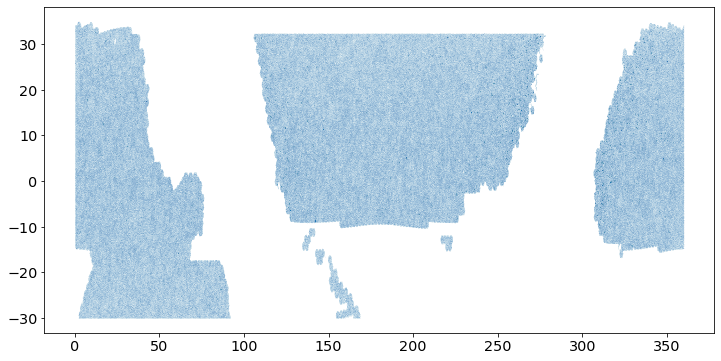

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(cat['RA'][::10], cat['DEC'][::10], '.', ms=0.1, alpha=0.1)
plt.show()

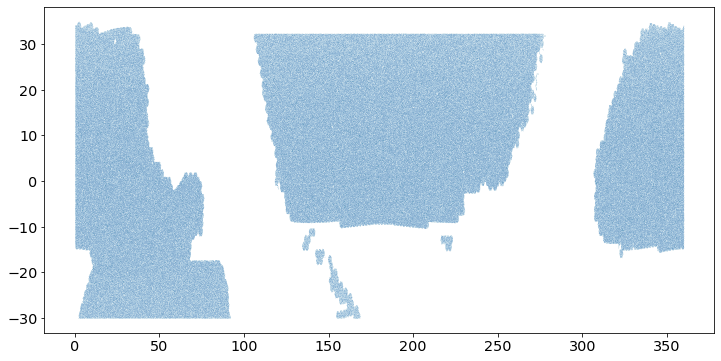

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(randoms['RA'][::10], randoms['DEC'][::10], '.', ms=0.1, alpha=0.1)
plt.show()

__Add MEDIUM and WISE masks and require NOBS>=2 (but do not apply them)__

In [15]:
maskbits = [1, 8, 11, 12, 13]
min_nobs = 2

cat_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    cat_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~cat_clean)/len(cat_clean))

randoms_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    randoms_clean &= (randoms['MASKBITS'] & 2**bit)==0
print(np.sum(~randoms_clean)/len(randoms_clean))
print()

cat_clean &= (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
print(np.sum(~cat_clean)/len(cat_clean))

randoms_clean &= (randoms['NOBS_G']>=min_nobs) & (randoms['NOBS_R']>=min_nobs) & (randoms['NOBS_Z']>=min_nobs)
print(np.sum(~randoms_clean)/len(randoms_clean))

0.08471961968318548
0.056166552896123406

0.1364825741195441
0.11060365511199727


In [16]:
area = len(randoms)/randoms_density
print('area = {:.1f}'.format(area))

area_clean = np.sum(randoms_clean)/randoms_density
print('clean area = {:.1f}'.format(area_clean))

area = 11366.2
clean area = 10109.0


In [17]:
downsample_factor = 1

def print_summary(mask, area):
    print('target density: {:.1f} per sq deg'.format(np.sum(mask)/area*downsample_factor))

In [18]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

In [42]:
# Changelog (v1.3):
# - Add GAIA_G>18 cut
# - Revised low-z (g-r vs r-W1) cuts from Jeff (same north and south cuts)
# - Shift the low-z cut intercept by 0.1 in the north (decreasing the density), to account for the north vs south difference
# - Shift the sliding IR cut intercept by 0.05*1.8 (increasing the density), to match the optical target density
# - Replace the low-z middle cut with a horizontal g-r>1.3 cut

# mask_north = cat['PHOTSYS']=='N'
# mask_south = cat['PHOTSYS']=='S'

#################### Updated optical selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.83) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.79) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.76) * 0.19       # low-z sliding optical cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_north = lrg_mask.copy()

lrg_opt = lrg_opt_south | lrg_opt_north
print(np.sum(lrg_opt))

#################### Updated IR selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.27) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.23) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_north = lrg_mask.copy()

lrg_ir = lrg_ir_south | lrg_ir_north
print(np.sum(lrg_ir))

7077840
7331192


In [43]:
print('Optical:', np.sum(lrg_opt))
print_summary(lrg_opt, area)

print('IR:', np.sum(lrg_ir))
print_summary(lrg_ir, area)

Optical: 7077840
target density: 622.7 per sq deg
IR: 7331192
target density: 645.0 per sq deg


In [44]:
# Add MEDIUM and WISE masks and require NOBS>=2

print('Optical:', np.sum(lrg_opt & cat_clean))
print_summary(lrg_opt & cat_clean, area_clean)

print('IR:', np.sum(lrg_ir & cat_clean))
print_summary(lrg_ir & cat_clean, area_clean)

Optical: 6228964
target density: 616.2 per sq deg
IR: 6252619
target density: 618.5 per sq deg


----------

In [45]:
# zfiber & sliding cut extension; 800 targets/sq.deg.

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.27) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.29
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_sv3_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.23) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.35
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_sv3_north = lrg_mask.copy()

lrg_sv3 = lrg_sv3_south | lrg_sv3_north
print(np.sum(lrg_sv3))

########################################################################

# zfiber extension & more restrictive sliding cut, with the same 600/sqdeg density as baseline

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.09) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.19) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_sv3_lowdens_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.05) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.15) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.45
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_sv3_lowdens_north = lrg_mask.copy()

lrg_sv3_lowdens = lrg_sv3_lowdens_south | lrg_sv3_lowdens_north
print(np.sum(lrg_sv3_lowdens))

9677319
7297523


In [46]:
print('SV3 full:', np.sum(lrg_sv3_south))
print_summary(lrg_sv3_south, area)

print('SV3 subset:', np.sum(lrg_sv3_lowdens_south))
print_summary(lrg_sv3_lowdens_south, area)

SV3 full: 9677319
target density: 851.4 per sq deg
SV3 subset: 7297523
target density: 642.0 per sq deg


In [47]:
# Add MEDIUM and WISE masks and require NOBS>=2

print('SV3 full:', np.sum(lrg_sv3_south & cat_clean))
print_summary(lrg_sv3_south & cat_clean, area_clean)

print('SV3 subset:', np.sum(lrg_sv3_lowdens_south & cat_clean))
print_summary(lrg_sv3_lowdens_south & cat_clean, area_clean)

SV3 full: 8265136
target density: 817.6 per sq deg
SV3 subset: 6165824
target density: 609.9 per sq deg
